#### Importing necessary libraries


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv('../data/coffe_quality.csv')

ID: no aprobechable
CoO: no


In [46]:
df_clean = df.copy()

In [47]:
columns_to_drop = [
    "Unnamed: 0", "ID", "Farm Name", "Lot Number", "Mill",
    "ICO Number", "Company", "Producer", "In-Country Partner",
    "Owner", "Grading Date", "Expiration", "Certification Body",
    "Certification Address", "Certification Contact"
]
df_clean = df_clean.drop(columns= columns_to_drop)

In [48]:
df_clean = df_clean.drop(columns = ["Region", "Altitude"])

In [49]:
df_clean["Bag Weight"] = df_clean["Bag Weight"].str.replace(" kg", "").astype(float)

In [50]:
df_clean["Harvest Year"] = df_clean["Harvest Year"].str.split("/").str[0]
df_clean["Harvest Year"] = pd.to_numeric(df_clean["Harvest Year"], errors="coerce")

In [60]:
thereshold = 10
counts = df_clean["Color"].value_counts()#df_clean["Variety"].value_counts()


In [61]:
df_clean["Color"] = df_clean["Color"].apply(
    lambda x: x if counts.get(x, 0) >= thereshold else "Other"
)

In [62]:
df_clean["Color"].value_counts()

Color
green           101
greenish         36
Other            27
bluish-green     21
blue-green       12
yellow-green     10
Name: count, dtype: int64

In [63]:
df_clean = pd.get_dummies(
    df_clean, columns=[
        "Country of Origin",
        "Variety",
        "Processing Method",
        "Color"
    ],
    drop_first= True
)

In [64]:
df_clean.dtypes

Number of Bags                                      int64
Bag Weight                                        float64
Harvest Year                                        int64
Status                                                str
Aroma                                             float64
Flavor                                            float64
Aftertaste                                        float64
Acidity                                           float64
Body                                              float64
Balance                                           float64
Uniformity                                        float64
Clean Cup                                         float64
Sweetness                                         float64
Overall                                           float64
Defects                                           float64
Total Cup Points                                  float64
Moisture Percentage                               float64
Category One D

In [65]:
df_clean = df_clean.drop(columns="Status")

In [66]:
import seaborn as sns


In [72]:
corr = df_clean.corr(numeric_only=True)

Total Cup Points                                  1.000000
Overall                                           0.947217
Flavor                                            0.939124
Aftertaste                                        0.934813
Balance                                           0.929520
Acidity                                           0.897057
Aroma                                             0.868919
Body                                              0.847216
Variety_Gesha                                     0.385756
Country of Origin_Taiwan                          0.241053
Country of Origin_Ethiopia                        0.172141
Processing Method_Other                           0.140007
Country of Origin_Guatemala                       0.115789
Country of Origin_Tanzania, United Republic Of    0.102933
Variety_Typica                                    0.042199
Bag Weight                                        0.038214
Country of Origin_Colombia                        0.0314

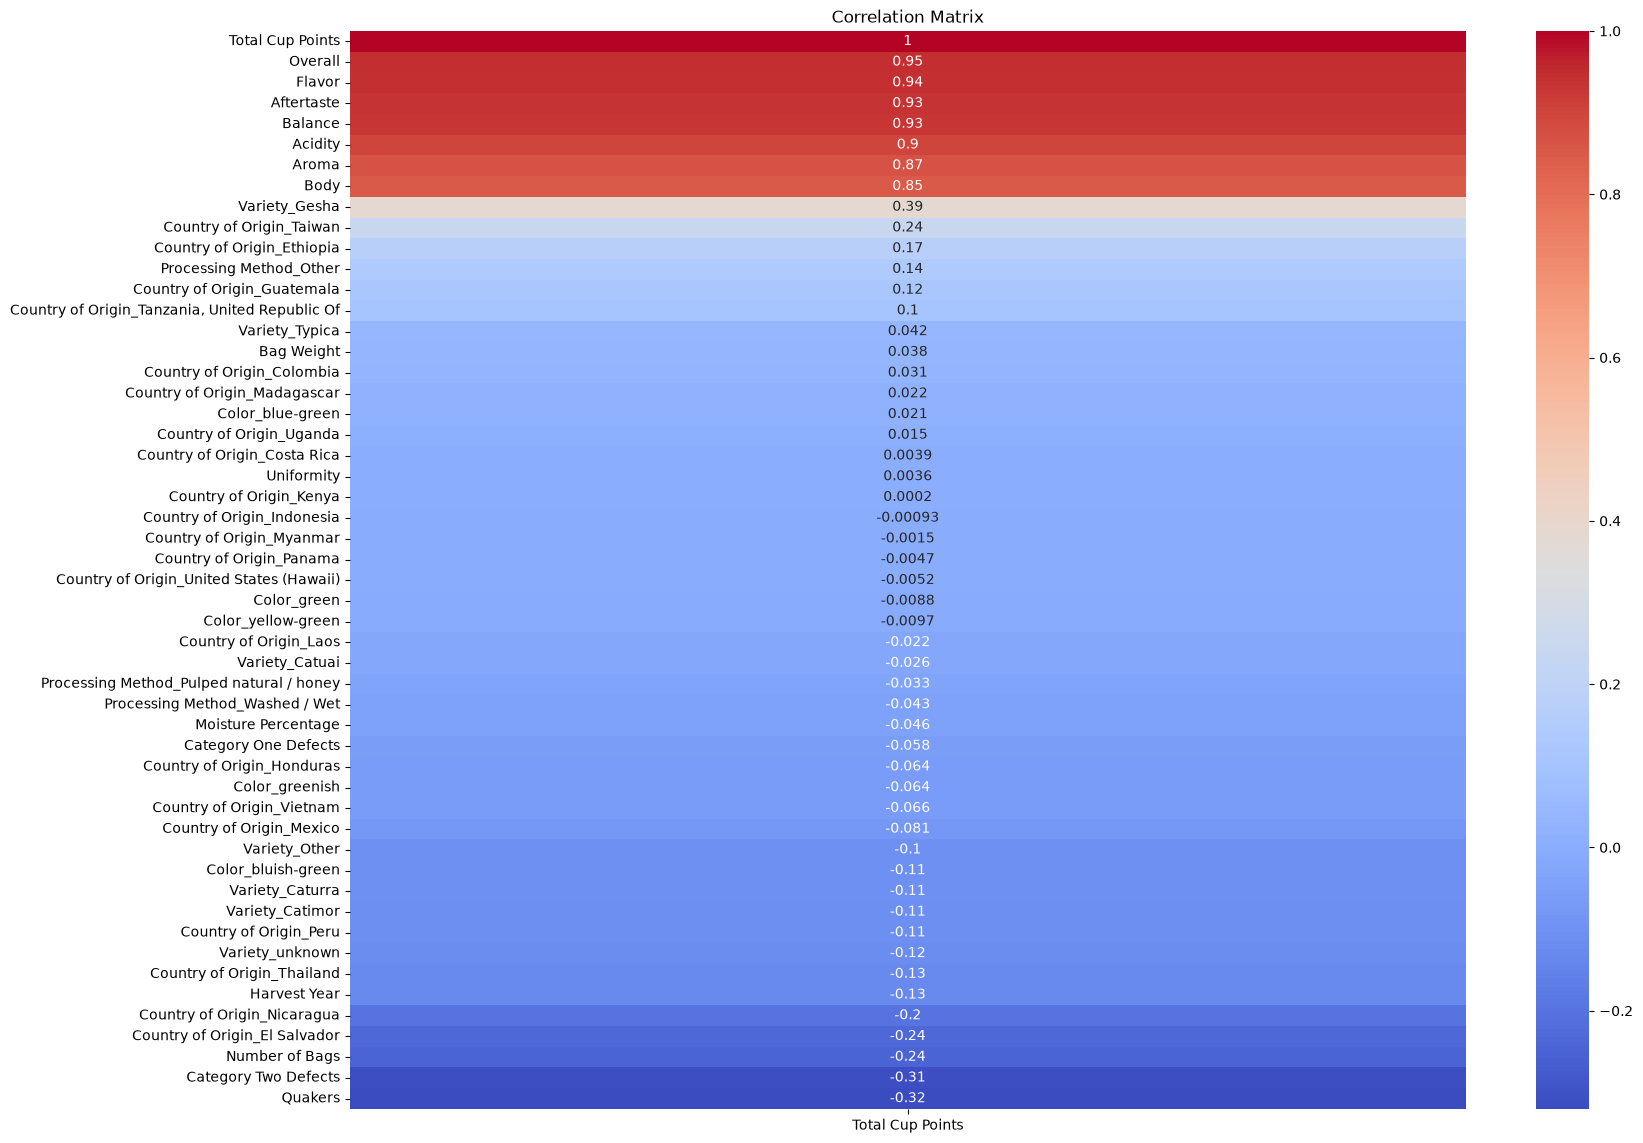

In [73]:
plt.figure(figsize=(18,14))
sns.heatmap(
    corr[["Total Cup Points"]].sort_values(
            by = "Total Cup Points",
            ascending=False
    ),
    annot=True,
    cmap="coolwarm"
    )
plt.title("Correlation Matrix")
plt.show()

In [70]:
df_clean = df_clean.drop(columns=["Sweetness", "Defects", "Clean Cup"])

In [74]:
df_clean.shape

(207, 52)

In [75]:
X = df_clean.drop(columns=["Total Cup Points"])
y = df_clean["Total Cup Points"]

In [76]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [77]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

TypeError: TransformerMixin.fit_transform() missing 1 required positional argument: 'X'